# **Retail Supply Chain & Inventory**

This project aims to analyze a supply chain and inventory management dataset containing 200,000 records. The analysis focuses on evaluating inventory levels, supplier performance, demand forecasting, financial metrics, and risk factors to optimize operations and drive data-driven decision-making.

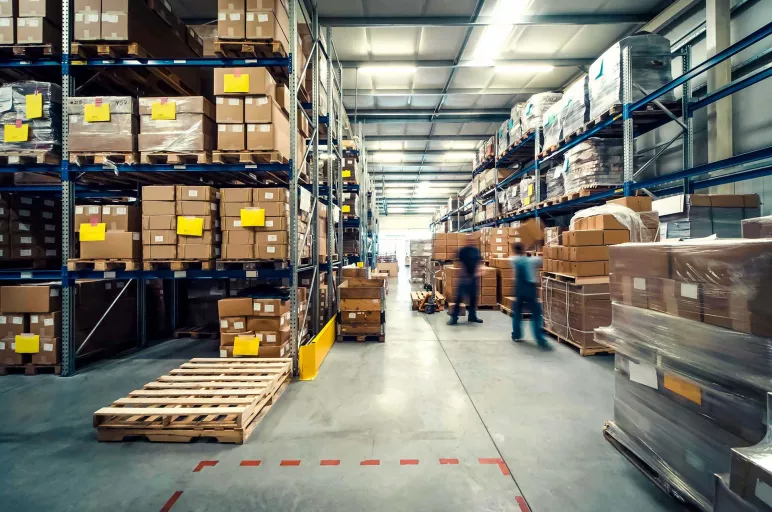

# **⏬ Install libraries**

# [ Cleaning & Preprocessing ]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/Retail_Supply_Chain_Analytics_Dataset (1).csv")
df

,Product_ID,Product_Category,Brand,SKU,Current_Stock,Reorder_Level,Safety_Stock,Inventory_Turnover,Supplier_ID,Supplier_Rating,...,Month,Quarter,Year,Demand_Forecast,Inventory_Optimization_Score,Supplier_Performance_Score,Supply_Chain_Efficiency,Sustainability_Score,Predicted_Reorder_Quantity,Operational_Risk_Score
0,PRD0000001,Fashion,BrandD,SKU191221,660,146,317,16.13,SUP1114,2.81,...,7,3,2025,6859,13.00,62.03,35.34,19.86,3949,3.99
1,PRD0000002,Home,BrandB,SKU116795,1681,176,219,1.11,SUP2811,2.77,...,9,3,2025,438,98.14,53.57,56.87,61.67,3820,39.96
2,PRD0000003,Electronics,BrandC,SKU344678,8195,714,109,8.38,SUP0815,5.00,...,4,2,2025,7961,17.37,6.47,87.55,35.81,1899,87.99
3,PRD0000004,Food,BrandC,SKU674236,4312,320,155,3.19,SUP0201,1.57,...,12,4,2023,19091,30.86,76.55,27.23,36.13,1288,70.06
4,PRD0000005,Fashion,BrandA,SKU327399,4067,981,222,5.85,SUP3354,1.53,...,6,2,2023,18036,31.06,19.25,20.44,92.92,4278,9.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,PRD0199996,Health,BrandA,SKU859978,2959,239,234,16.31,SUP1475,4.59,...,4,2,2024,19522,39.92,80.19,41.55,98.93,1665,89.55
199996,PRD0199997,Electronics,BrandB,SKU202886,3934,817,451,12.69,SUP1113,1.31,...,7,3,2023,652,42.06,29.43,74.13,31.04,184,55.82
199997,PRD0199998,Food,BrandC,SKU437940,1391,394,20,8.81,SUP1327,3.12,...,8,3,2024,14470,36.43,24.02,57.35,67.62,1332,12.41
199998,PRD0199999,Fashion,BrandB,SKU130179,603,892,23,19.83,SUP1799,4.47,...,10,4,2023,11772,71.86,36.00,70.33,61.48,1683,49.27


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Product_ID                    200000 non-null  object 
 1   Product_Category              200000 non-null  object 
 2   Brand                         200000 non-null  object 
 3   SKU                           200000 non-null  object 
 4   Current_Stock                 200000 non-null  int64  
 5   Reorder_Level                 200000 non-null  int64  
 6   Safety_Stock                  200000 non-null  int64  
 7   Inventory_Turnover            200000 non-null  float64
 8   Supplier_ID                   200000 non-null  object 
 9   Supplier_Rating               200000 non-null  float64
 10  Lead_Time_Days                200000 non-null  int64  
 11  Warehouse_ID                  200000 non-null  object 
 12  Warehouse_Location            200000 non-nul

In [4]:
df.describe()

,Current_Stock,Reorder_Level,Safety_Stock,Inventory_Turnover,Supplier_Rating,Lead_Time_Days,Storage_Capacity,Utilization_Rate,Units_Sold,Daily_Demand,...,Month,Quarter,Year,Demand_Forecast,Inventory_Optimization_Score,Supplier_Performance_Score,Supply_Chain_Efficiency,Sustainability_Score,Predicted_Reorder_Quantity,Operational_Risk_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,5001.120900,505.412565,254.189080,10.017377,3.000134,44.990320,50435.756755,50.000285,2500.743275,249.691480,...,6.523425,2.509160,2023.996725,9983.548125,49.919329,49.959190,50.010358,50.008608,2504.190990,50.002700
std,2891.173975,286.002597,141.454268,5.780697,1.152276,25.684268,28589.927260,28.859697,1445.086336,144.627209,...,3.451533,1.117932,0.817097,5777.391338,28.883356,28.881403,28.899704,28.858756,1443.826487,28.884754
min,0.000000,10.000000,10.000000,0.000000,1.000000,1.000000,1001.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,2023.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2495.000000,257.000000,131.000000,5.010000,2.000000,23.000000,25655.000000,25.040000,1253.000000,124.000000,...,4.000000,2.000000,2023.000000,4975.000000,24.900000,24.970000,24.900000,25.080000,1254.750000,24.960000
50%,5000.000000,507.000000,254.000000,10.040000,3.000000,45.000000,50278.000000,50.010000,2496.000000,249.000000,...,7.000000,3.000000,2024.000000,9965.000000,49.830000,49.870000,50.030000,50.020000,2507.000000,49.960000
75%,7507.000000,754.000000,376.000000,15.020000,4.000000,67.000000,75206.000000,74.930000,3755.000000,375.000000,...,10.000000,4.000000,2025.000000,14979.000000,74.890000,74.940000,75.020000,75.010000,3756.000000,75.030000
max,9999.000000,999.000000,499.000000,20.000000,5.000000,89.000000,99998.000000,100.000000,4999.000000,499.000000,...,12.000000,4.000000,2025.000000,19999.000000,100.000000,100.000000,100.000000,100.000000,4999.000000,100.000000


In [5]:
df.isnull().sum()

,0
Product_ID,0
Product_Category,0
Brand,0
SKU,0
Current_Stock,0
Reorder_Level,0
Safety_Stock,0
Inventory_Turnover,0
Supplier_ID,0
Supplier_Rating,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

In [8]:
mismatch = (
    (df['Date'].dt.month != df['Month']) |
    (df['Date'].dt.quarter != df['Quarter']) |
    (df['Date'].dt.year != df['Year'])
).sum()
print(mismatch)

0


In [9]:
numeric_cols = df.select_dtypes(include='number').columns
q1, q3 = df[numeric_cols].quantile(0.25), df[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr

outliers = ((df[numeric_cols] < lower) | (df[numeric_cols] > upper)).sum()
outliers[outliers > 0].sort_values(ascending=False)

,0


# [   **Feature Engineering**    ]

In [10]:
df["Stock_Cover_Days"] = (
    df["Current_Stock"] / df["Daily_Demand"].replace(0, np.nan)
    )
df[["Current_Stock", "Daily_Demand", "Stock_Cover_Days"]].head(10)

,Current_Stock,Daily_Demand,Stock_Cover_Days
0,660,430,1.534884
1,1681,395,4.255696
2,8195,169,48.491124
3,4312,200,21.560000
4,4067,417,9.752998
5,1695,236,7.182203
6,749,214,3.500000
7,8110,22,368.636364
8,6278,25,251.120000
9,4959,287,17.278746


In [11]:
df["Sell_Through_Rate"] = (
    df["Units_Sold"] /
    (df["Units_Sold"] + df["Current_Stock"]).replace(0, np.nan)
) * 100

In [12]:
df["Safety_Stock_Ratio"] = (
    df["Safety_Stock"] /
    df["Current_Stock"].replace(0, np.nan)
) * 100

In [13]:
df["Inventory_Gap"] = (
    df["Current_Stock"] - df["Reorder_Level"]
)
df[["Current_Stock", "Reorder_Level", "Inventory_Gap"]].head(5)

,Current_Stock,Reorder_Level,Inventory_Gap
0,660,146,514
1,1681,176,1505
2,8195,714,7481
3,4312,320,3992
4,4067,981,3086


In [14]:
df["Needs_Reorder"] = np.where(
    df["Current_Stock"] <= df["Reorder_Level"],
    "Yes",
    "No"
)

In [15]:
df["Forecast_Error"] = (
    df["Units_Sold"] - df["Demand_Forecast"]
)
df[["Units_Sold", "Demand_Forecast", "Forecast_Error"]].head(5)

,Units_Sold,Demand_Forecast,Forecast_Error
0,3424,6859,-3435
1,1366,438,928
2,2761,7961,-5200
3,1954,19091,-17137
4,2875,18036,-15161


In [16]:
df["Forecast_Accuracy"] = (
    1 - (
        abs(df["Units_Sold"] - df["Demand_Forecast"]) /
        df["Units_Sold"].replace(0, np.nan)
    )
) * 100

df["Forecast_Accuracy"] = df["Forecast_Accuracy"].clip(0, 100)

In [17]:
df["Profit_Margin"] = (
    df["Profit_USD"] /
    df["Revenue_USD"].replace(0, np.nan)
) * 100

In [18]:
df["Demand_Stock_Ratio"] = (
    df["Monthly_Demand"] /
    df["Current_Stock"].replace(0, np.nan)
)

# [   **EDA**    ] : 📊 Visualization & Insights


Correlation Matrix Heatmap
   


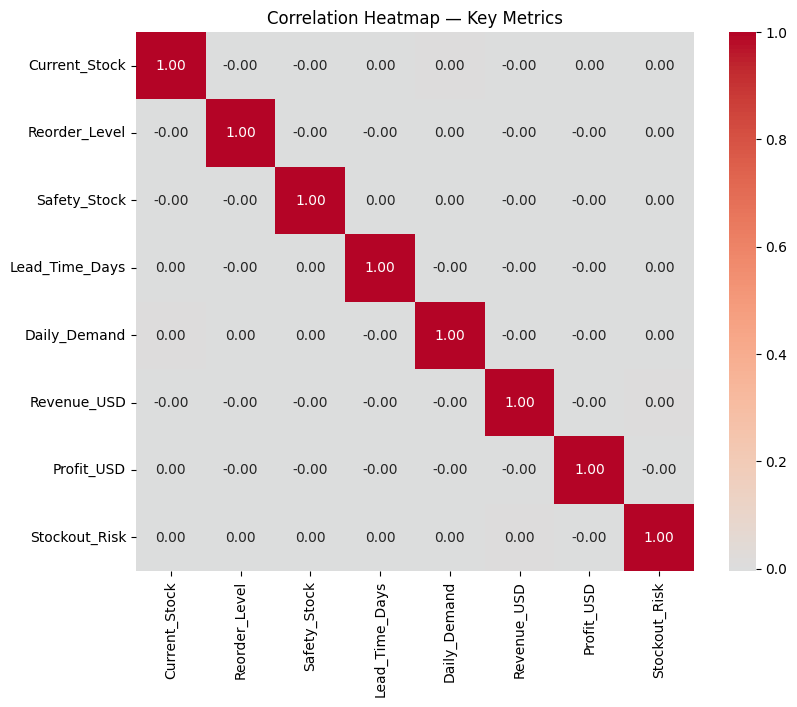

In [19]:
key_cols = ['Current_Stock', 'Reorder_Level', 'Safety_Stock', 'Lead_Time_Days',
            'Daily_Demand', 'Revenue_USD', 'Profit_USD', 'Stockout_Risk']

plt.figure(figsize=(9, 7))
sns.heatmap(df[key_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Key Metrics')
plt.show()

Univariate Correlation

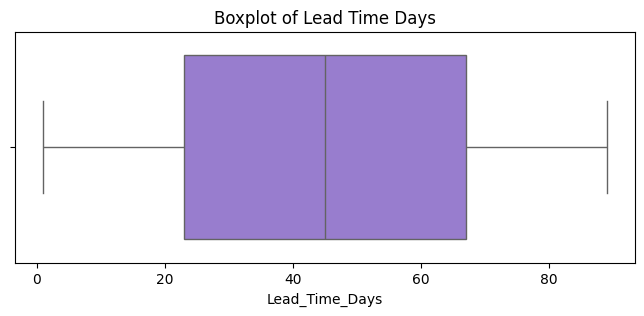

In [20]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['Lead_Time_Days'], color='mediumpurple')
plt.title('Boxplot of Lead Time Days')
plt.show()

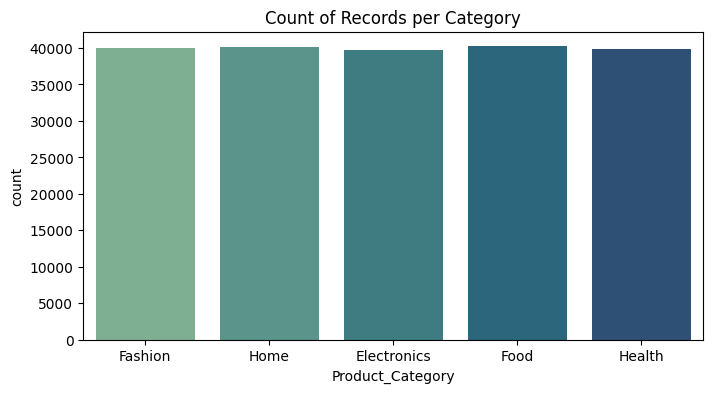

In [21]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Product_Category', palette='crest', hue='Product_Category', legend=False)
plt.title('Count of Records per Category')
plt.show()

Bivariate Correlation

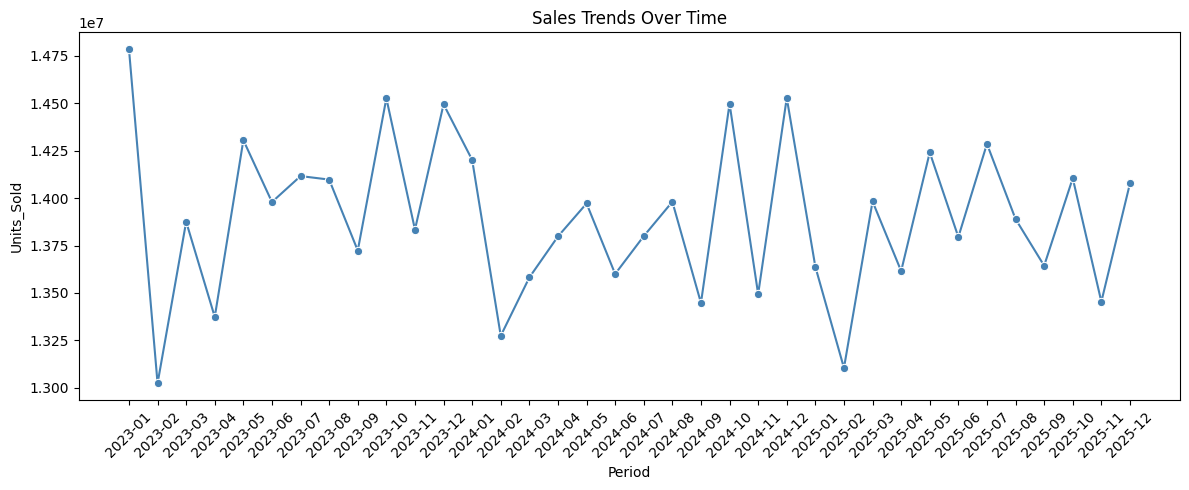

In [22]:
sales = df.groupby(["Year", "Month"])["Units_Sold"].sum().reset_index()
sales["Period"] = sales["Year"].astype(str) + "-" + sales["Month"].astype(str).str.zfill(2)

plt.figure(figsize=(12,5))
sns.lineplot(data=sales, x="Period", y="Units_Sold", marker="o", color="steelblue")
plt.title("Sales Trends Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

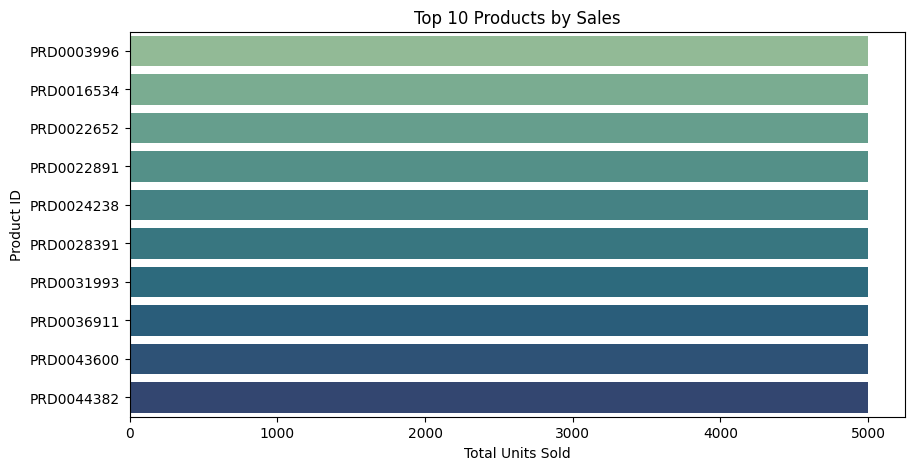

In [23]:
top_products = df.groupby("Product_ID")["Units_Sold"].sum().nlargest(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index,
            hue=top_products.index, palette="crest", legend=False)
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Units Sold")
plt.ylabel("Product ID")
plt.show()

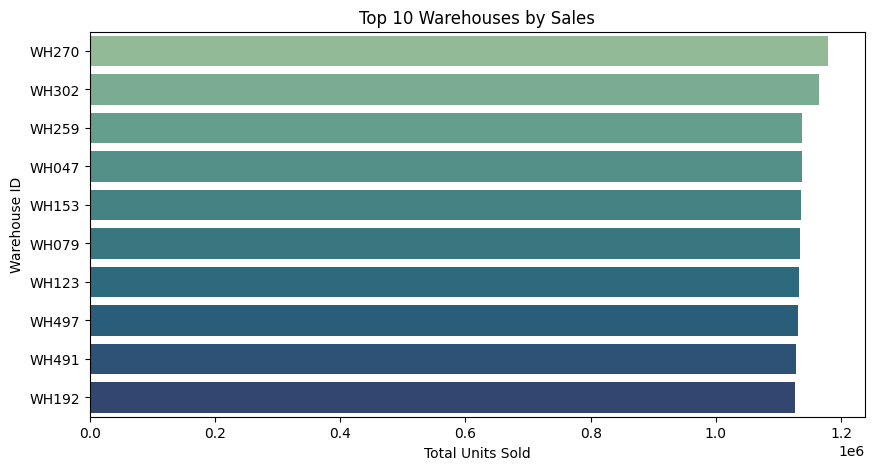

In [24]:
top_warehouses = df.groupby("Warehouse_ID")["Units_Sold"].sum().nlargest(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_warehouses.values, y=top_warehouses.index,
            hue=top_warehouses.index, palette="crest", legend=False)
plt.title("Top 10 Warehouses by Sales")
plt.xlabel("Total Units Sold")
plt.ylabel("Warehouse ID")
plt.show()

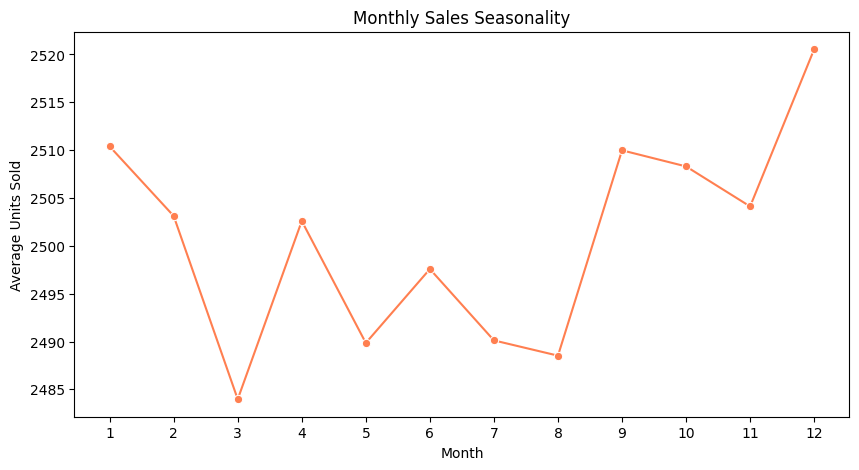

In [25]:
seasonality = df.groupby("Month")["Units_Sold"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=seasonality, x="Month", y="Units_Sold",
             marker="o", color="coral")
plt.title("Monthly Sales Seasonality")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.xticks(range(1,13))
plt.show()

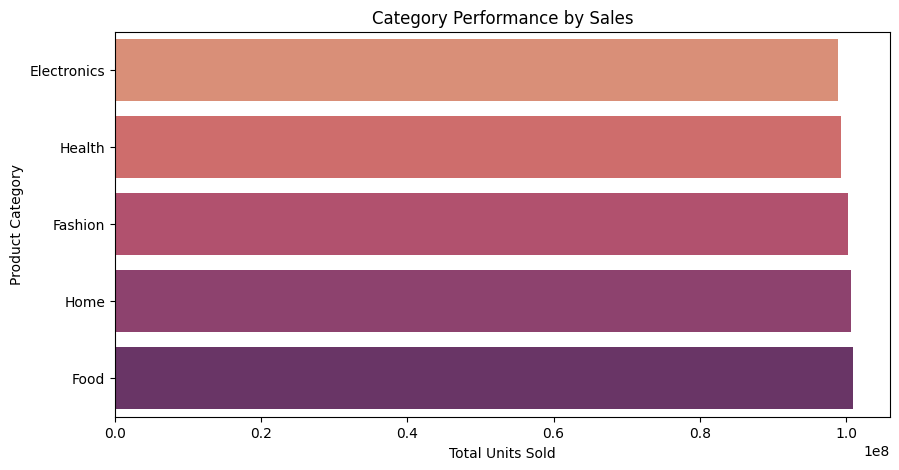

In [26]:
category = df.groupby("Product_Category")["Units_Sold"].sum().sort_values()

plt.figure(figsize=(10,5))
sns.barplot(x=category.values, y=category.index,
            hue=category.index, palette="flare", legend=False)
plt.title("Category Performance by Sales")
plt.xlabel("Total Units Sold")
plt.ylabel("Product Category")
plt.show()

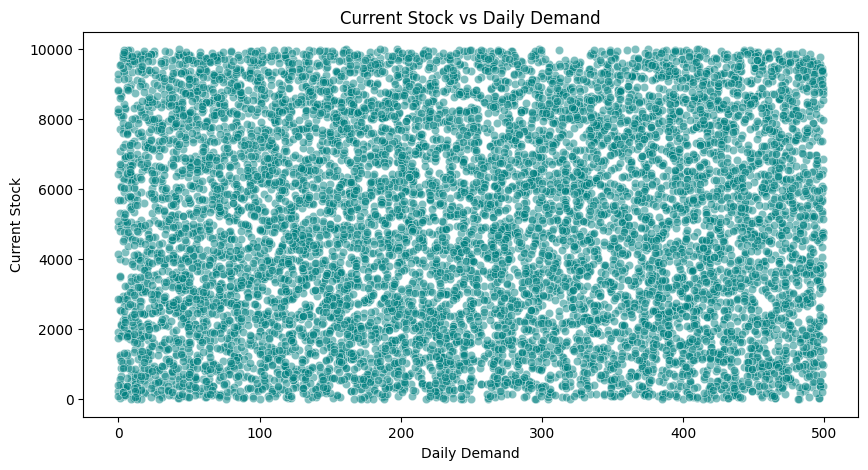

In [27]:
sample = df.sample(min(10000, len(df)), random_state=42)

plt.figure(figsize=(10,5))
sns.scatterplot(data=sample, x="Daily_Demand", y="Current_Stock",
                color="teal", alpha=.5)
plt.title("Current Stock vs Daily Demand")
plt.xlabel("Daily Demand")
plt.ylabel("Current Stock")
plt.show()

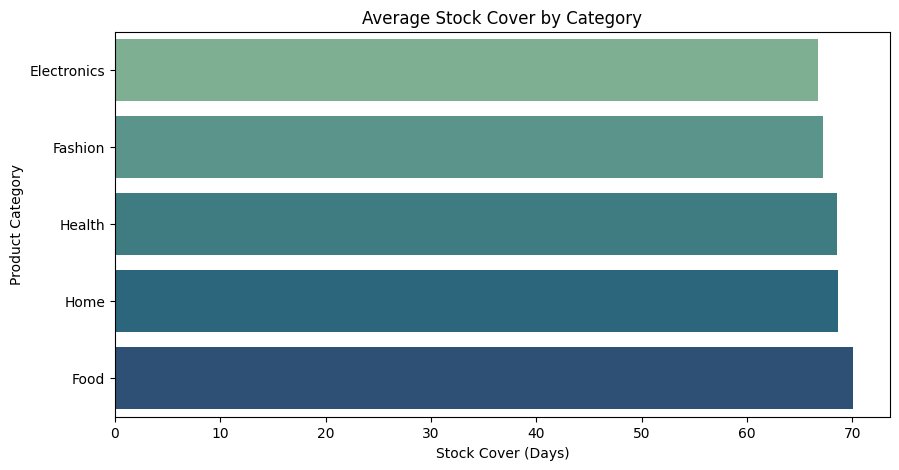

In [28]:
stock = df.groupby("Product_Category")["Stock_Cover_Days"].mean().sort_values()

plt.figure(figsize=(10,5))
sns.barplot(x=stock.values, y=stock.index,
            hue=stock.index, palette="crest", legend=False)
plt.title("Average Stock Cover by Category")
plt.xlabel("Stock Cover (Days)")
plt.ylabel("Product Category")
plt.show()

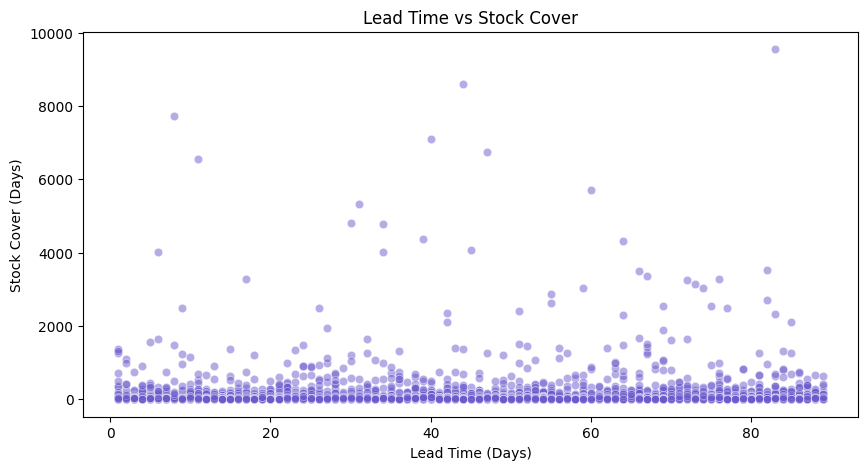

In [29]:
sample = df.sample(min(10000, len(df)), random_state=42)

plt.figure(figsize=(10,5))
sns.scatterplot(data=sample, x="Lead_Time_Days", y="Stock_Cover_Days",
                color="slateblue", alpha=.5)
plt.title("Lead Time vs Stock Cover")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Stock Cover (Days)")
plt.show()

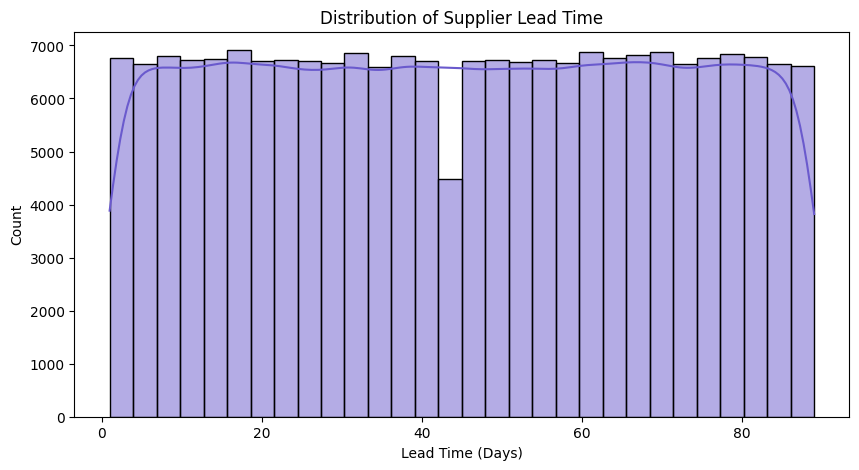

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Lead_Time_Days'], bins=30, kde=True, color='slateblue')
plt.title('Distribution of Supplier Lead Time')
plt.xlabel('Lead Time (Days)')
plt.show()

# [  **INSIGHTS**  ]


In [31]:
print("Top Product:", df.groupby("Product_ID")["Units_Sold"].sum().idxmax())
print("Top Warehouse:", df.groupby("Warehouse_ID")["Units_Sold"].sum().idxmax())
print("Best Category:", df.groupby("Product_Category")["Units_Sold"].sum().idxmax())

Top Product: PRD0003996
Top Warehouse: WH270
Best Category: Food


<> **Sales analysis shows that product PRD0003996 is the top-performing product, while WH270 is the top-performing warehouse. Among the product categories, Food has the highest overall sales indicating strong demand for this category**

In [32]:
monthly = df.groupby("Month")["Units_Sold"].mean()

print("Peak Month:", monthly.idxmax())
print("Lowest Month:", monthly.idxmin())

Peak Month: 12
Lowest Month: 3


<> **Seasonality analysis shows that December (Month 12) has the highest average demand, while March (Month 3) has the lowest average demand. This indicates a clear seasonal pattern in customer demand, with demand peaking at the end of the year.**

In [33]:
print("Average Stock Cover:",
      round(df["Stock_Cover_Days"].mean(), 2), "days")

print("Average Sell-Through Rate:",
      round(df["Sell_Through_Rate"].mean(), 2), "%")

Average Stock Cover: 68.22 days
Average Sell-Through Rate: 36.93 %


<> **The average stock cover is 68.22 days, meaning that the available inventory can cover approximately 68 days of demand on average. The average sell-through rate is 36.93%, indicating that around 37% of the available inventory is sold, suggesting that some products may have relatively slow inventory movement.**

In [34]:
reorder = (df["Current_Stock"] <= df["Reorder_Level"]).sum()

print("Records Needing Reorder:", reorder)

Records Needing Reorder: 10094


<> **10,094 records require inventory replenishment because their current stock is at or below the reorder level. This indicates a significant need for restocking to reduce the risk of stockouts**

In [35]:
print("Average Lead Time:",
      round(df["Lead_Time_Days"].mean(), 2), "days")

Average Lead Time: 44.99 days


<> **The average lead time is 44.99 days, indicating that suppliers require approximately 45 days on average to replenish inventory**

# [  **Data Validation for Daily Demand**  ]

In [36]:
df = df.sort_values('Date')

In [37]:
print(df[['Date', 'Daily_Demand']].head(10))

             Date  Daily_Demand
179540 2023-01-01            12
181454 2023-01-01           376
162507 2023-01-01           389
7139   2023-01-01           328
168320 2023-01-01           335
155484 2023-01-01           440
130706 2023-01-01           396
65878  2023-01-01           345
189863 2023-01-01            47
169780 2023-01-01           279


In [38]:
daily_counts = df['Date'].value_counts()

print(daily_counts.head(10))

Date
2024-12-22    235
2025-03-09    228
2024-02-06    225
2023-06-27    224
2024-10-27    222
2023-02-15    220
2024-04-12    220
2025-05-30    220
2025-05-10    217
2024-12-30    216
Name: count, dtype: int64


In [39]:
print(df['Date'].nunique())

1095


In [40]:
print(df.groupby('Date').size().describe())

count    1095.000000
mean      182.648402
std        13.828462
min       132.000000
25%       173.000000
50%       183.000000
75%       192.000000
max       235.000000
dtype: float64


In [41]:
duplicates_per_product_day = df.duplicated(
    subset=['Date', 'Product_ID']
).sum()

print("Duplicate Product-Date records:", duplicates_per_product_day)

Duplicate Product-Date records: 0


In [42]:
print("Unique Products:", df['Product_ID'].nunique())

Unique Products: 200000


Prepare Daily Demand

##  Demand Forecasting

The objective of this section is to build a baseline demand forecasting
model using historical daily demand.

A Moving Average model is selected as the baseline because it is simple,
interpretable, computationally efficient, and suitable for establishing
a benchmark for future forecasting models.

In [43]:
daily_demand = (
    df.groupby("Date")["Daily_Demand"]
    .sum()
    .reset_index()
    .sort_values("Date")
)

print("Number of observations:", len(daily_demand))
print(
    "Date range:",
    daily_demand["Date"].min(),
    "to",
    daily_demand["Date"].max()
)

daily_demand.head()

Number of observations: 1095
Date range: 2023-01-01 00:00:00 to 2025-12-30 00:00:00


,Date,Daily_Demand
0,2023-01-01,44488
1,2023-01-02,46156
2,2023-01-03,48249
3,2023-01-04,43016
4,2023-01-05,45708


Check Time Series

In [44]:
print("Missing values:")
print(daily_demand.isnull().sum())

print("\nDuplicate dates:")
print(daily_demand["Date"].duplicated().sum())

full_dates = pd.date_range(
    start=daily_demand["Date"].min(),
    end=daily_demand["Date"].max(),
    freq="D"
)

missing_dates = full_dates.difference(daily_demand["Date"])

print("\nNumber of missing dates:", len(missing_dates))

print(
    "Dates are sorted:",
    daily_demand["Date"].is_monotonic_increasing
)

Missing values:
Date            0
Daily_Demand    0
dtype: int64

Duplicate dates:
0

Number of missing dates: 0
Dates are sorted: True


###  Train/Test Split

The dataset is split chronologically into 80% training data and 20%
testing data. A chronological split is used because demand forecasting
is a time-series problem and future observations must not be used to
train the model.

In [45]:
train_size = int(len(daily_demand) * 0.8)

train = daily_demand.iloc[:train_size].copy()
test = daily_demand.iloc[train_size:].copy()

print("Training size:", len(train))
print("Testing size:", len(test))

print("\nTraining period:")
print(train["Date"].min(), "to", train["Date"].max())

print("\nTesting period:")
print(test["Date"].min(), "to", test["Date"].max())

Training size: 876
Testing size: 219

Training period:
2023-01-01 00:00:00 to 2025-05-25 00:00:00

Testing period:
2025-05-26 00:00:00 to 2025-12-30 00:00:00


### Demand Overview

In [46]:
daily_demand["Daily_Demand"].describe()

,Daily_Demand
count,1095.000000
mean,45605.749772
std,3965.046809
min,31632.000000
25%,43128.000000
50%,45463.000000
75%,48130.000000
max,58643.000000


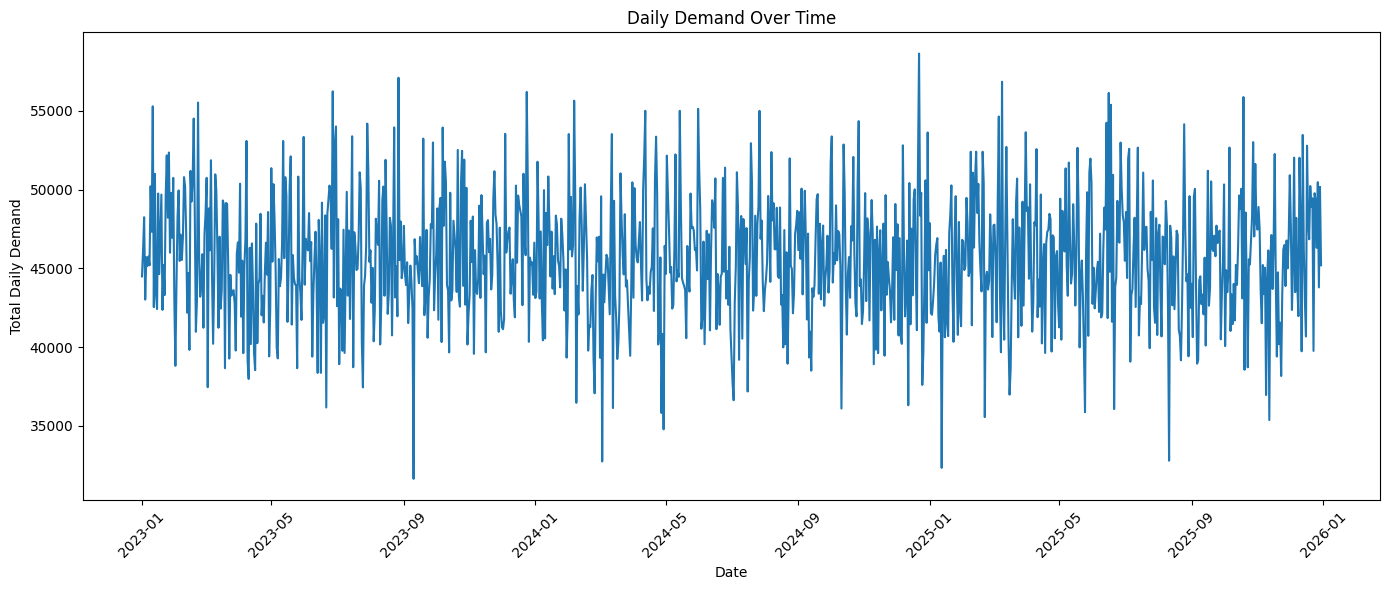

In [47]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_demand["Date"],
    daily_demand["Daily_Demand"]
)

plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Daily Demand")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###  Moving Average Exploration

Different moving-average windows are explored to determine which window
provides the best forecasting performance.

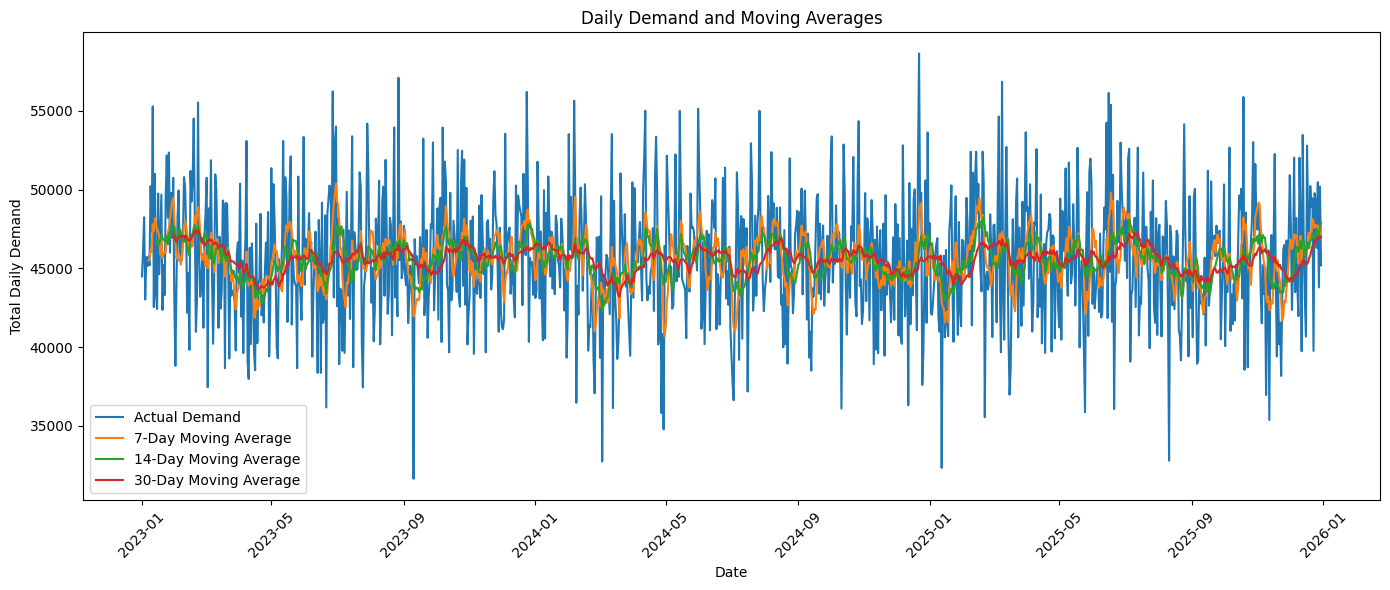

In [48]:
for window in [7, 14, 30]:
    daily_demand[f"MA_{window}"] = (
        daily_demand["Daily_Demand"]
        .rolling(window=window)
        .mean()
    )

plt.figure(figsize=(14, 6))

plt.plot(
    daily_demand["Date"],
    daily_demand["Daily_Demand"],
    label="Actual Demand"
)

plt.plot(
    daily_demand["Date"],
    daily_demand["MA_7"],
    label="7-Day Moving Average"
)

plt.plot(
    daily_demand["Date"],
    daily_demand["MA_14"],
    label="14-Day Moving Average"
)

plt.plot(
    daily_demand["Date"],
    daily_demand["MA_30"],
    label="30-Day Moving Average"
)

plt.title("Daily Demand and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Total Daily Demand")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

windows = [7, 14, 30]

results = []

for window in windows:

    history = list(train["Daily_Demand"].values)

    predictions = []

    for i in range(len(test)):

        forecast = np.mean(history[-window:])

        predictions.append(forecast)

        history.append(forecast)

    mae = mean_absolute_error(
        test["Daily_Demand"],
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            test["Daily_Demand"],
            predictions
        )
    )

    results.append({
        "Window": window,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)

print(results_df)

   Window          MAE         RMSE
0       7  5052.737035  6072.991639
1      14  3613.754338  4558.098591
2      30  3217.790075  4061.867786


In [50]:
best_window = results_df.loc[
    results_df["MAE"].idxmin(),
    "Window"
]

print("Best Window:", best_window)

Best Window: 30


### Final Test Forecast

In [51]:
history = list(train["Daily_Demand"].values)

predictions = []

for i in range(len(test)):

    forecast = np.mean(history[-best_window:])

    predictions.append(forecast)

    history.append(forecast)

forecast_results = test[["Date", "Daily_Demand"]].copy()

forecast_results["Forecast"] = predictions

print(forecast_results.head(10))

          Date  Daily_Demand      Forecast
876 2025-05-26         46044  45238.866667
877 2025-05-27         49835  45180.928889
878 2025-05-28         40715  45335.059852
879 2025-05-29         51080  45320.228514
880 2025-05-30         51971  45294.369464
881 2025-05-31         50428  45380.448446
882 2025-06-01         42745  45518.063394
883 2025-06-02         45042  45387.765508
884 2025-06-03         42458  45551.691024
885 2025-06-04         43575  45448.347392


### Evaluation

In [52]:
actual = forecast_results["Daily_Demand"]
forecast = forecast_results["Forecast"]

mae = mean_absolute_error(actual, forecast)

rmse = np.sqrt(
    mean_squared_error(actual, forecast)
)

mape = (
    np.abs(actual - forecast)
    / actual.replace(0, np.nan)
).mean() * 100

print("Best Window:", best_window)
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

Best Window: 30
MAE: 3217.790074636377
RMSE: 4061.867786386164
MAPE: 7.031989670454919


### Actual vs Forecast

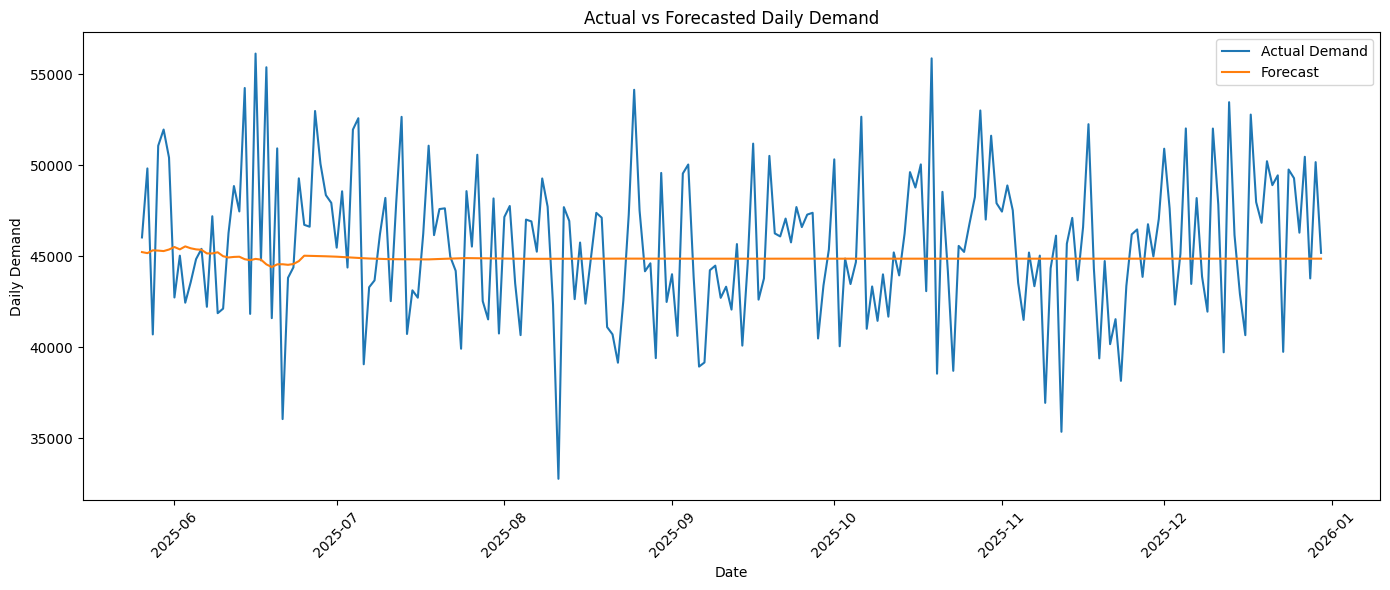

In [53]:
plt.figure(figsize=(14, 6))

plt.plot(
    forecast_results["Date"],
    forecast_results["Daily_Demand"],
    label="Actual Demand"
)

plt.plot(
    forecast_results["Date"],
    forecast_results["Forecast"],
    label="Forecast"
)

plt.title("Actual vs Forecasted Daily Demand")
plt.xlabel("Date")
plt.ylabel("Daily Demand")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [54]:
from sklearn.metrics import mean_absolute_percentage_error

mape_30 = mean_absolute_percentage_error(
    actual,
    forecast
) * 100

print("MAPE:", mape_30, "%")

MAPE: 7.031989670454919 %


### Error Analysis

In [55]:
forecast_results['Error'] = (
    forecast_results['Daily_Demand']
    - forecast_results['Forecast']
)

forecast_results['Absolute_Error'] = (
    forecast_results['Error'].abs()
)

forecast_results['Percentage_Error'] = (
    forecast_results['Absolute_Error']
    / forecast_results['Daily_Demand']
) * 100

print(forecast_results.head(10))

          Date  Daily_Demand      Forecast        Error  Absolute_Error  \
876 2025-05-26         46044  45238.866667   805.133333      805.133333   
877 2025-05-27         49835  45180.928889  4654.071111     4654.071111   
878 2025-05-28         40715  45335.059852 -4620.059852     4620.059852   
879 2025-05-29         51080  45320.228514  5759.771486     5759.771486   
880 2025-05-30         51971  45294.369464  6676.630536     6676.630536   
881 2025-05-31         50428  45380.448446  5047.551554     5047.551554   
882 2025-06-01         42745  45518.063394 -2773.063394     2773.063394   
883 2025-06-02         45042  45387.765508  -345.765508      345.765508   
884 2025-06-03         42458  45551.691024 -3093.691024     3093.691024   
885 2025-06-04         43575  45448.347392 -1873.347392     1873.347392   

     Percentage_Error  
876          1.748617  
877          9.338961  
878         11.347316  
879         11.275982  
880         12.846839  
881         10.009422  
882   

In [56]:
bias = forecast_results['Error'].mean()

print("Forecast Bias:", bias)

Forecast Bias: 746.6158667663979


In [57]:
under_forecast_days = (
    forecast_results['Error'] > 0
).sum()

over_forecast_days = (
    forecast_results['Error'] < 0
).sum()

print("Under-forecasting days:", under_forecast_days)
print("Over-forecasting days:", over_forecast_days)

Under-forecasting days: 124
Over-forecasting days: 95


In [58]:
largest_errors = forecast_results.sort_values(
    'Absolute_Error',
    ascending=False
)

print(
    largest_errors[
        [
            'Date',
            'Daily_Demand',
            'Forecast',
            'Error',
            'Absolute_Error',
            'Percentage_Error'
        ]
    ].head(10)
)

           Date  Daily_Demand      Forecast         Error  Absolute_Error  \
953  2025-08-11         32782  44870.654964 -12088.654964    12088.654964   
897  2025-06-16         56144  44864.753677  11279.246323    11279.246323   
1022 2025-10-19         55882  44876.597823  11005.402177    11005.402177   
899  2025-06-18         55393  44563.634760  10829.365240    10829.365240   
1046 2025-11-12         35366  44876.604729  -9510.604729     9510.604729   
895  2025-06-14         54254  44847.406149   9406.593851     9406.593851   
967  2025-08-25         54155  44878.664657   9276.335343     9276.335343   
1077 2025-12-13         53474  44876.598787   8597.401213     8597.401213   
902  2025-06-21         36064  44570.502190  -8506.502190     8506.502190   
1031 2025-10-28         53019  44876.573919   8142.426081     8142.426081   

      Percentage_Error  
953          36.875892  
897          20.089852  
1022         19.694002  
899          19.550061  
1046         26.891943  
89

### Future 30-Day Forecast

In [59]:
history = list(daily_demand["Daily_Demand"].values)

future_predictions = []

for i in range(30):

    forecast = np.mean(history[-best_window:])

    future_predictions.append(forecast)

    history.append(forecast)

future_dates = pd.date_range(
    start=daily_demand["Date"].max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_predictions
})

future_forecast.head(30)

,Date,Forecast
0,2025-12-31,46984.300000
1,2026-01-01,46853.176667
2,2026-01-02,46826.782556
3,2026-01-03,46975.708641
4,2026-01-04,47036.598929
5,2026-01-05,46870.085560
6,2026-01-06,46982.755078
7,2026-01-07,46941.946914
8,2026-01-08,47043.711811
9,2026-01-09,47212.968872


In [60]:
print(future_forecast.head())
print(future_forecast.tail())

        Date      Forecast
0 2025-12-31  46984.300000
1 2026-01-01  46853.176667
2 2026-01-02  46826.782556
3 2026-01-03  46975.708641
4 2026-01-04  47036.598929
         Date      Forecast
25 2026-01-25  47112.442779
26 2026-01-26  47139.357539
27 2026-01-27  47028.169457
28 2026-01-28  47136.075105
29 2026-01-29  47034.577609


In [61]:
df.to_csv("cleaned_retail_supply_chain.csv", index=False)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


In [62]:
forecast_results.to_csv(
    "demand_forecast_results.csv",
    index=False
)

print("Forecast results exported successfully.")

Forecast results exported successfully.


In [63]:
future_forecast.to_csv(
    "future_30_day_forecast.csv",
    index=False
)

print("Future 30-day forecast exported successfully.")

Future 30-day forecast exported successfully.
